Практическая часть экзамена
Построение модели Logistic Regression, расчет метрик и анализ важности признаков.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

plt.rcParams['figure.figsize'] = (8, 5)

data = pd.read_csv('gotovo.csv')
data = data.fillna(data.median(numeric_only=True))
X = data.drop('churn', axis=1)
y = data['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
data.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male,balance_per_product,age_group
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False,0.00,1.0
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False,41903.93,1.0
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False,39915.20,1.0
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False,0.00,1.0
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False,62755.41,1.0


Разделение данных и обучение модели

In [2]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
model.fit(X_train, y_train)
pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, pred))
print('Precision:', precision_score(y_test, pred))
print('Recall:', recall_score(y_test, pred))
print('F1:', f1_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8095
Precision: 0.5955882352941176
Recall: 0.19901719901719903
F1: 0.2983425414364641
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1593
           1       0.60      0.20      0.30       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



Важность признаков

In [3]:
coefs = model.named_steps['model'].coef_[0]
importance = pd.DataFrame({'Признак': X.columns, 'Коэффициент': coefs, 'Важность': abs(coefs)}).sort_values('Важность', ascending=False)
importance

,Признак,Коэффициент,Важность
1,age,0.545440,0.545440
6,active_member,-0.516267,0.516267
3,balance,0.411843,0.411843
8,country_Germany,0.352271,0.352271
11,balance_per_product,-0.279792,0.279792
10,gender_Male,-0.261426,0.261426
12,age_group,0.215159,0.215159
4,products_number,-0.140492,0.140492
0,credit_score,-0.085961,0.085961
7,estimated_salary,0.046892,0.046892


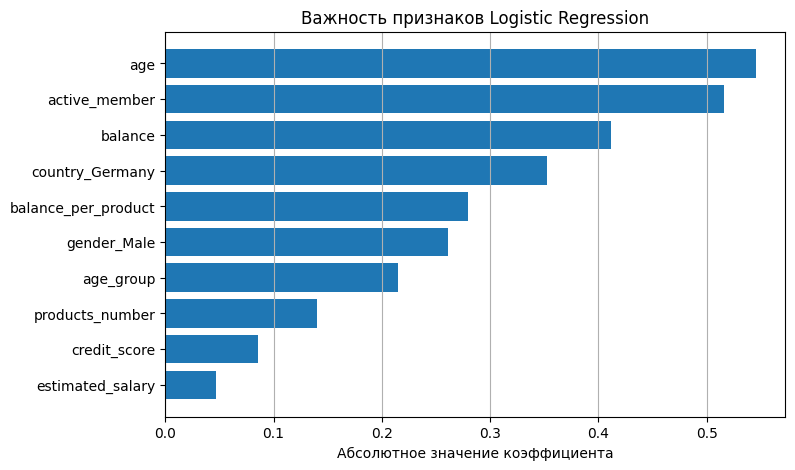

In [4]:
top = importance.head(10)
plt.barh(top['Признак'], top['Важность'])
plt.gca().invert_yaxis()
plt.title('Важность признаков Logistic Regression')
plt.xlabel('Абсолютное значение коэффициента')
plt.grid(axis='x')
plt.show()

Ответы на вопросы:
1.Что такое EDA?
EDA — это исследовательский анализ данных. На этом этапе изучают структуру датасета, типы признаков, пропуски, выбросы, распределения и связи между переменными. Основные этапы EDA: загрузка данных, просмотр первых строк, анализ типов данных, описательная статистика, проверка пропусков, поиск выбросов, анализ корреляций и изучение целевой переменной. Пропуски можно удалить или заполнить средним, медианой, модой. Выбросы ищут через boxplot, IQR и описательную статистику. Feature engineering — создание новых полезных признаков, например balance_per_product и age_group.
2.Подготовка данных перед обучением
Перед обучением данные очищают и приводят к числовому виду. Категориальные признаки кодируют с помощью One-Hot Encoding или Label Encoding. Числовые признаки масштабируют с помощью StandardScaler или MinMaxScaler. Нерелевантные признаки удаляют, например customer_id, так как он является техническим идентификатором и не отражает поведение клиента.
3.Переобучение и повышение качества
Переобучение — ситуация, когда модель хорошо работает на обучающих данных, но плохо на новых. Для борьбы с ним используют train/test split, кросс-валидацию, регуляризацию, ограничение глубины моделей, подбор гиперпараметров и сравнение алгоритмов. GridSearchCV перебирает параметры и помогает выбрать лучший вариант модели.



Вывод
Модель логистической регрессии построена для прогнозирования оттока клиентов банка. Метрики позволяют оценить качество классификации, а анализ коэффициентов показывает, какие признаки сильнее всего влияют на прогноз. Модель можно использовать для предварительного выявления клиентов с риском ухода.